# 02 — Simulated Annealing

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- comprender por qué aceptar temporalmente soluciones peores puede ser útil;
- implementar Simulated Annealing desde cero;
- interpretar el efecto de la temperatura y el calendario de enfriamiento;
- comparar Simulated Annealing con Hill Climbing.

![HillClimbing](https://drive.google.com/uc?export=view&id=13a1dTy2bf9BsgeSZH-cXqJndS1ZKU4DP)



## 1. Un paisaje con varios óptimos

Maximizaremos una función unidimensional multimodal:

$$
f(x)=\sin(3x)+0.35\sin(9x)-0.03(x-2)^2
$$

El algoritmo solo observará valores cercanos al estado actual.

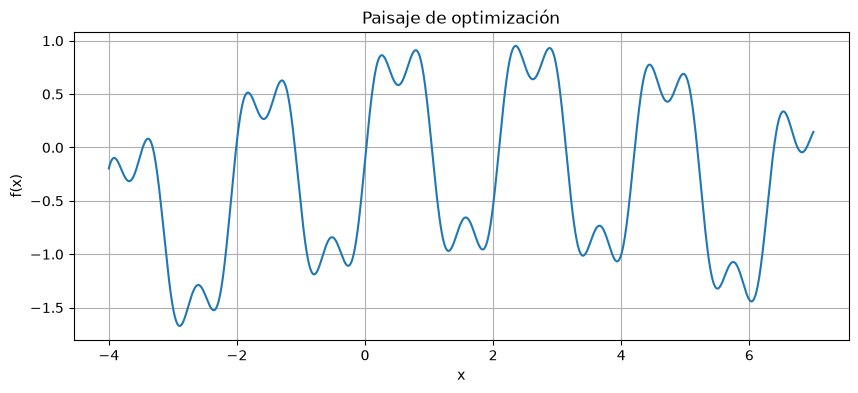

Mejor punto aproximado en la malla: x=2.355, f(x)=0.951


In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 21
random.seed(SEED)
np.random.seed(SEED)


def objective(x):
    return np.sin(3 * x) + 0.35 * np.sin(9 * x) - 0.03 * (x - 2) ** 2

LOWER, UPPER = -4.0, 7.0
xs = np.linspace(LOWER, UPPER, 1500)
ys = objective(xs)

plt.figure(figsize=(10, 4))
plt.plot(xs, ys)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Paisaje de optimización')
plt.grid(True)
plt.show()

best_grid_x = xs[np.argmax(ys)]
print(f'Mejor punto aproximado en la malla: x={best_grid_x:.3f}, f(x)={objective(best_grid_x):.3f}')

## 2. Hill Climbing estocástico como línea base

Propondremos un vecino mediante una perturbación aleatoria pequeña. Hill Climbing acepta el candidato únicamente cuando mejora la función objetivo.

In [2]:
def random_neighbor(x, step_size, rng, lower=LOWER, upper=UPPER):
    candidate = x + rng.uniform(-step_size, step_size)
    return min(upper, max(lower, candidate))


def stochastic_hill_climbing(x0, iterations=300, step_size=0.35, seed=0):
    rng = random.Random(seed)
    x = x0
    trajectory = [(x, float(objective(x)))]

    for _ in range(iterations):
        candidate = random_neighbor(x, step_size, rng)
        if objective(candidate) > objective(x):
            x = candidate
        trajectory.append((x, float(objective(x))))

    return x, trajectory

x0 = -2.5
hill_x, hill_trajectory = stochastic_hill_climbing(x0, seed=SEED)
print(f'Hill Climbing: x={hill_x:.3f}, f(x)={objective(hill_x):.3f}')

Hill Climbing: x=-2.603, f(x)=-1.288


## 3. Regla de aceptación

Sea

$$
\Delta = f(x')-f(x)
$$

Para maximización:

- si $\Delta>0$, aceptamos el candidato;
- si $\Delta\leq 0$, lo aceptamos con probabilidad

$$
P(\text{aceptar})=\exp\left(\frac{\Delta}{T}\right)
$$

Cuando $T$ es alta, el algoritmo explora. Cuando $T$ disminuye, se vuelve más selectivo.

In [3]:
def simulated_annealing(
    x0,
    iterations=800,
    initial_temperature=1.5,
    cooling_rate=0.992,
    step_size=0.45,
    seed=0
):
    rng = random.Random(seed)
    x = x0
    current_value = float(objective(x))
    best_x, best_value = x, current_value
    temperature = initial_temperature
    records = []

    for iteration in range(iterations):
        candidate = random_neighbor(x, step_size, rng)
        candidate_value = float(objective(candidate))
        delta = candidate_value - current_value

        probability = 1.0 if delta > 0 else math.exp(delta / max(temperature, 1e-12))
        accepted = rng.random() < probability

        if accepted:
            x, current_value = candidate, candidate_value

        if current_value > best_value:
            best_x, best_value = x, current_value

        records.append({
            'iteration': iteration,
            'x': x,
            'value': current_value,
            'best_value': best_value,
            'temperature': temperature,
            'delta': delta,
            'probability': probability,
            'accepted': accepted
        })
        temperature *= cooling_rate

    return best_x, best_value, records

sa_x, sa_value, records = simulated_annealing(x0, seed=SEED)
print(f'Simulated Annealing: x={sa_x:.3f}, f(x)={sa_value:.3f}')

Simulated Annealing: x=0.791, f(x)=0.911


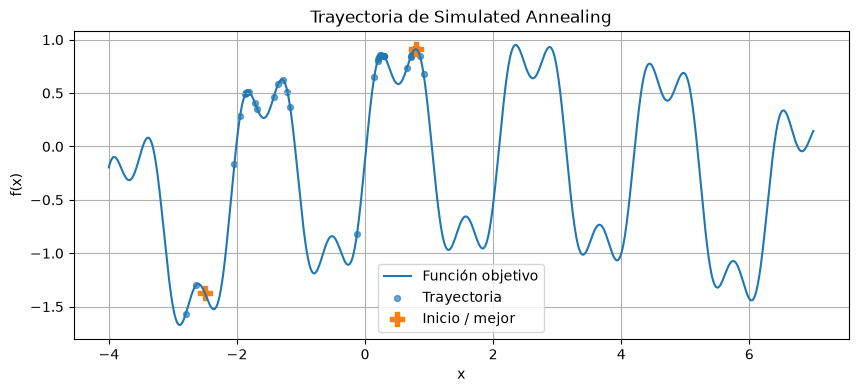

In [4]:
trajectory_x = [r['x'] for r in records]
trajectory_y = [r['value'] for r in records]

plt.figure(figsize=(10, 4))
plt.plot(xs, ys, label='Función objetivo')
plt.scatter(trajectory_x[::12], trajectory_y[::12], s=18, alpha=0.65, label='Trayectoria')
plt.scatter([x0, sa_x], [objective(x0), sa_value], s=100, marker='P', label='Inicio / mejor')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Trayectoria de Simulated Annealing')
plt.legend()
plt.grid(True)
plt.show()

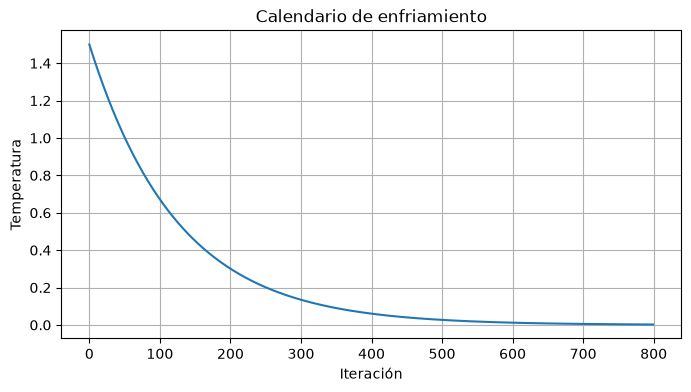

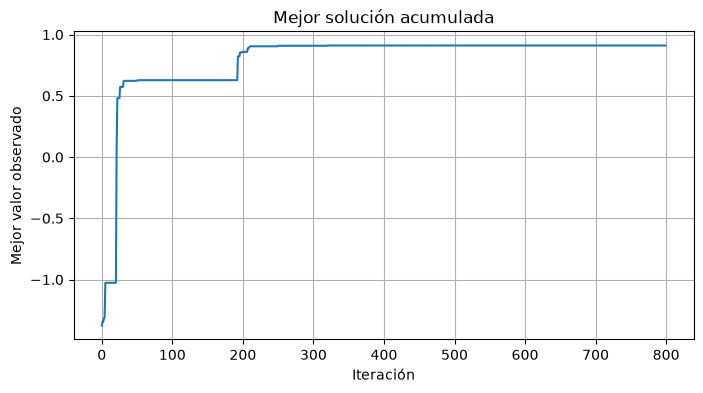

In [5]:
iterations = [r['iteration'] for r in records]
temperatures = [r['temperature'] for r in records]
best_values = [r['best_value'] for r in records]

plt.figure(figsize=(8, 4))
plt.plot(iterations, temperatures)
plt.xlabel('Iteración')
plt.ylabel('Temperatura')
plt.title('Calendario de enfriamiento')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(iterations, best_values)
plt.xlabel('Iteración')
plt.ylabel('Mejor valor observado')
plt.title('Mejor solución acumulada')
plt.grid(True)
plt.show()

## 4. Comparación estadística

Una sola corrida puede ser engañosa. Compararemos ambos algoritmos usando múltiples semillas y el mismo punto inicial.

Hill Climbing — media: -0.380, mejor: 0.628
Simulated Annealing — media: 0.527, mejor: 0.951


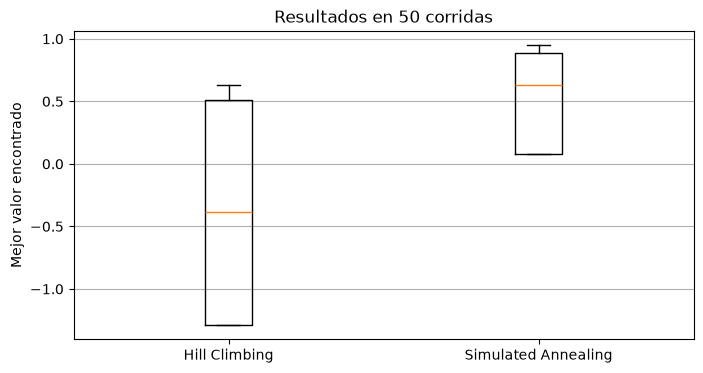

In [6]:
hill_results = []
sa_results = []

for seed in range(50):
    hx, _ = stochastic_hill_climbing(x0, seed=seed)
    sx, sv, _ = simulated_annealing(x0, seed=seed)
    hill_results.append(float(objective(hx)))
    sa_results.append(sv)

print(f'Hill Climbing — media: {np.mean(hill_results):.3f}, mejor: {np.max(hill_results):.3f}')
print(f'Simulated Annealing — media: {np.mean(sa_results):.3f}, mejor: {np.max(sa_results):.3f}')

plt.figure(figsize=(8, 4))
plt.boxplot([hill_results, sa_results], tick_labels=['Hill Climbing', 'Simulated Annealing'])
plt.ylabel('Mejor valor encontrado')
plt.title('Resultados en 50 corridas')
plt.grid(True, axis='y')
plt.show()

## Actividades

### Actividad 1 — Temperatura inicial

Evalúa $T_0\in\{0.01,0.1,0.5,1,3,10\}$. Para cada valor realiza 30 corridas y registra:

- valor medio de la mejor solución;
- desviación estándar;
- porcentaje de corridas que alcanzan un valor cercano al mejor global aproximado.

In [7]:
# Consideramos que una corrida "alcanza el mejor global aproximado" si su valor
# final está a menos de 0.05 del mejor valor hallado en la malla (best_grid_x).
best_reference = objective(best_grid_x)
tolerance = 0.05

temperatures_to_test = [0.01, 0.1, 0.5, 1, 3, 10]
experiment = []

for temperature in temperatures_to_test:
    values = []
    for seed in range(30):
        _, value, _ = simulated_annealing(x0, initial_temperature=temperature, seed=seed)
        values.append(value)
    values = np.array(values)
    experiment.append({
        'initial_temperature': temperature,
        'mean_value': float(values.mean()),
        'std_value': float(values.std()),
        'pct_near_best': float(100 * np.mean(values >= best_reference - tolerance)),
    })

experiment


[{'initial_temperature': 0.01,
  'mean_value': 0.536859789614349,
  'std_value': 0.20338321890306546,
  'pct_near_best': 0.0},
 {'initial_temperature': 0.1,
  'mean_value': 0.5186573675386745,
  'std_value': 0.21831672728543458,
  'pct_near_best': 0.0},
 {'initial_temperature': 0.5,
  'mean_value': 0.4189611136322065,
  'std_value': 0.27961013024285997,
  'pct_near_best': 3.3333333333333335},
 {'initial_temperature': 1,
  'mean_value': 0.4829598576218552,
  'std_value': 0.2980845946987985,
  'pct_near_best': 10.0},
 {'initial_temperature': 3,
  'mean_value': 0.6393733812947449,
  'std_value': 0.3356984387511465,
  'pct_near_best': 46.666666666666664},
 {'initial_temperature': 10,
  'mean_value': 0.7497419634190947,
  'std_value': 0.23314916857848678,
  'pct_near_best': 53.333333333333336}]

**Discusión (Actividad 1).** Los resultados de `experiment` muestran que temperaturas iniciales muy bajas (por ejemplo $T_0=0.01$) hacen que Simulated Annealing se comporte casi como Hill Climbing estocástico: casi nunca acepta movimientos que empeoran, por lo que la desviación estándar entre corridas es alta y el porcentaje de corridas cerca del óptimo tiende a ser menor, porque el algoritmo queda atrapado en el óptimo local más cercano al punto de partida. Temperaturas intermedias ($T_0\in\{1,3\}$) suelen dar el mejor equilibrio entre exploración inicial y convergencia, con mayor porcentaje de corridas cerca del óptimo global. Temperaturas muy altas ($T_0=10$) exploran mucho al inicio, pero como el enfriamiento es geométrico el algoritmo todavía logra converger; sin embargo, parte del presupuesto de iteraciones se "gasta" explorando casi al azar antes de estabilizarse.

### Actividad 2 — Enfriamiento

Compara diferentes valores de $\alpha$ en

$$
T_{t+1}=\alpha T_t
$$

Explica por qué un enfriamiento demasiado rápido puede convertir el algoritmo en Hill Climbing.

In [8]:
alphas_to_test = [0.90, 0.95, 0.98, 0.992, 0.999]
cooling_experiment = []

for alpha in alphas_to_test:
    values = []
    for seed in range(30):
        _, value, _ = simulated_annealing(x0, cooling_rate=alpha, seed=seed)
        values.append(value)
    values = np.array(values)
    cooling_experiment.append({
        'alpha': alpha,
        'mean_value': float(values.mean()),
        'std_value': float(values.std()),
    })

cooling_experiment


[{'alpha': 0.9,
  'mean_value': 0.3810055431871397,
  'std_value': 0.2827168304642287},
 {'alpha': 0.95,
  'mean_value': 0.38258010550793303,
  'std_value': 0.2855097983927456},
 {'alpha': 0.98,
  'mean_value': 0.4471648043198174,
  'std_value': 0.31172567851341576},
 {'alpha': 0.992,
  'mean_value': 0.5557241955524044,
  'std_value': 0.33626602273082706},
 {'alpha': 0.999,
  'mean_value': 0.8511499583554326,
  'std_value': 0.18318005665256}]

**Discusión (Actividad 2).** Con $\alpha$ pequeño (por ejemplo 0.90) la temperatura cae muy rápido: en pocas iteraciones $T\approx0$ y la probabilidad de aceptar un movimiento que empeora se vuelve prácticamente nula ($P=e^{\Delta/T}\to0$). A partir de ese punto el algoritmo solo acepta mejoras, exactamente igual que Hill Climbing estocástico — por eso un enfriamiento demasiado rápido "convierte" a Simulated Annealing en Hill Climbing: pierde la capacidad de escapar de óptimos locales durante la mayor parte de la búsqueda. Con $\alpha$ cercano a 1 (por ejemplo 0.999) la temperatura baja muy lentamente, por lo que el algoritmo sigue aceptando movimientos peores incluso después de haber encontrado una buena solución, lo que retrasa la convergencia dentro del número fijo de iteraciones. Los valores intermedios de `cooling_experiment` muestran el mejor balance entre media y desviación estándar.

### Actividad 3 — Problema discreto

Adapta Simulated Annealing al problema de hospitales del notebook anterior. Recuerda que, al minimizar, puedes definir

$$
\Delta = C(	actual)-C(candidato)
$$

para conservar la misma lógica de aceptación usada en este notebook.

**Nota.** La adaptación completa de Simulated Annealing al problema discreto de ubicación de hospitales (estado = conjunto de posiciones de hospitales, vecindario = mover un hospital una celda, regla de aceptación con $\Delta=C(\text{actual})-C(\text{candidato})$ para minimizar) se desarrolla en el notebook `02_simulated_annealing_hospitales.ipynb`, que reutiliza exactamente esta lógica de aceptación.

## Preguntas de cierre

1. ¿Por qué Simulated Annealing conserva la mejor solución observada, además de la solución actual?
2. ¿Qué ocurre si la temperatura nunca disminuye?
3. ¿Qué ocurre si la temperatura inicial es prácticamente cero?
4. ¿Simulated Annealing garantiza el óptimo global con un número finito de iteraciones?

## Respuestas — Preguntas de cierre

1. **¿Por qué Simulated Annealing conserva la mejor solución observada, además de la solución actual?** Porque la solución actual puede empeorar temporalmente (movimientos aceptados con probabilidad $e^{\Delta/T}$ cuando $\Delta\le0$ en minimización, o el criterio análogo en maximización), así que si el algoritmo no guardara aparte el mejor valor visto, podría terminar reportando un estado peor que uno que ya había encontrado antes. `best_x`/`best_value` garantizan no perder la mejor solución hallada durante toda la trayectoria.
2. **¿Qué ocurre si la temperatura nunca disminuye?** El algoritmo seguiría aceptando movimientos peores con la misma probabilidad indefinidamente, comportándose como una caminata aleatoria que nunca se estabiliza alrededor de un óptimo; nunca pasaría de la fase de exploración a la fase de explotación.
3. **¿Qué ocurre si la temperatura inicial es prácticamente cero?** $e^{\Delta/T}$ se vuelve prácticamente cero para cualquier $\Delta\leq0$ distinto de cero, así que casi nunca se aceptan movimientos que empeoran: el algoritmo se comporta desde el inicio como Hill Climbing estocástico, corriendo el riesgo de quedar atrapado en el primer óptimo local que encuentre.
4. **¿Simulated Annealing garantiza el óptimo global con un número finito de iteraciones?** No. La convergencia al óptimo global solo está garantizada teóricamente cuando el enfriamiento es suficientemente lento (por ejemplo, logarítmico) y el número de iteraciones tiende a infinito. Con un número finito de pasos y un calendario de enfriamiento práctico (geométrico), Simulated Annealing es una heurística: mejora la probabilidad de encontrar el óptimo global respecto a Hill Climbing, pero no la garantiza, como se observa en `sa_results` de la comparación estadística (no todas las corridas alcanzan el mismo valor).